# RETAIL SALES EDA PROJECT 

# Relevant Libriries Importation and Raw Data Loading

In [1]:
#Import Relevant Packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Loading Raw DataSet
raw_csv_data = pd.read_csv("retail_sales_raw.csv")
raw_data = raw_csv_data.copy()

# Basic Data Overview

In [3]:
pd.options.display.max_columns = None
pd.options.display.max_rows = None

In [4]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TransactionID  5050 non-null   int64  
 1   CustomerID     5050 non-null   int64  
 2   ProductID      5050 non-null   int64  
 3   Quantity       5050 non-null   int64  
 4   UnitPrice      4950 non-null   float64
 5   Discount       5050 non-null   float64
 6   Region         3936 non-null   object 
 7   PaymentMethod  4008 non-null   object 
 8   InvoiceDate    5050 non-null   object 
dtypes: float64(2), int64(4), object(3)
memory usage: 355.2+ KB


In [5]:
raw_data.describe()

,TransactionID,CustomerID,ProductID,Quantity,UnitPrice,Discount
count,5050.000000,5050.000000,5050.000000,5050.000000,4950.000000,5050.000000
mean,12499.514257,1505.389901,300.616832,5.002574,252.890855,0.152315
std,1442.142588,290.669438,57.570375,2.598084,143.730304,0.086309
min,10000.000000,1000.000000,200.000000,1.000000,5.080000,0.000000
25%,11252.250000,1253.000000,252.000000,3.000000,127.342500,0.080000
50%,12499.500000,1510.000000,300.000000,5.000000,250.315000,0.150000
75%,13747.750000,1760.000000,351.000000,7.000000,380.597500,0.230000
max,14999.000000,1999.000000,399.000000,9.000000,499.900000,0.300000


In [6]:
raw_data.head()

,TransactionID,CustomerID,ProductID,Quantity,UnitPrice,Discount,Region,PaymentMethod,InvoiceDate
0,10000,1102,319,3,100.90,0.25,Kano,Card,2023-06-02
1,10001,1435,325,9,134.57,0.27,Abuja,Card,2023-07-21
2,10002,1860,254,1,258.73,0.06,Port Harcourt,POS,2023-11-17
3,10003,1270,226,5,168.65,0.19,Port Harcourt,Transfer,2024-04-08
4,10004,1106,317,2,430.95,0.28,NaN,Card,2023-01-11


# Conversion of Date column

In [7]:
raw_data["InvoiceDate"] = pd.to_datetime(raw_data["InvoiceDate"])

In [8]:
raw_data["Year"] = raw_data["InvoiceDate"].dt.year
raw_data["Month"] = raw_data["InvoiceDate"].dt.month
raw_data["Weekday"] = raw_data["InvoiceDate"].dt.day_name()

In [9]:
raw_data.head()

,TransactionID,CustomerID,ProductID,Quantity,UnitPrice,Discount,Region,PaymentMethod,InvoiceDate,Year,Month,Weekday
0,10000,1102,319,3,100.90,0.25,Kano,Card,2023-06-02,2023,6,Friday
1,10001,1435,325,9,134.57,0.27,Abuja,Card,2023-07-21,2023,7,Friday
2,10002,1860,254,1,258.73,0.06,Port Harcourt,POS,2023-11-17,2023,11,Friday
3,10003,1270,226,5,168.65,0.19,Port Harcourt,Transfer,2024-04-08,2024,4,Monday
4,10004,1106,317,2,430.95,0.28,NaN,Card,2023-01-11,2023,1,Wednesday


In [10]:
updated_data=raw_data.copy()

## Fixing missing values and duplicates

In [11]:
updated_data.isnull().sum()

TransactionID       0
CustomerID          0
ProductID           0
Quantity            0
UnitPrice         100
Discount            0
Region           1114
PaymentMethod    1042
InvoiceDate         0
Year                0
Month               0
Weekday             0
dtype: int64

In [12]:
updated_data["UnitPrice"].fillna(updated_data['UnitPrice'].median(), inplace=True)   

In [13]:
updated_data["Region"].fillna(updated_data['Region'].mode()[0], inplace=True)   

In [14]:
updated_data["PaymentMethod"].fillna(updated_data['PaymentMethod'].mode()[0], inplace=True) 

In [15]:
updated_data.duplicated().sum()

48

In [16]:
updated_data = updated_data.drop_duplicates()

In [17]:
updated_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5002 entries, 0 to 5046
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   TransactionID  5002 non-null   int64         
 1   CustomerID     5002 non-null   int64         
 2   ProductID      5002 non-null   int64         
 3   Quantity       5002 non-null   int64         
 4   UnitPrice      5002 non-null   float64       
 5   Discount       5002 non-null   float64       
 6   Region         5002 non-null   object        
 7   PaymentMethod  5002 non-null   object        
 8   InvoiceDate    5002 non-null   datetime64[ns]
 9   Year           5002 non-null   int64         
 10  Month          5002 non-null   int64         
 11  Weekday        5002 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(6), object(3)
memory usage: 508.0+ KB


## Feature Engineering

In [18]:
updated_data["TotalSales"] = updated_data["Quantity"] * updated_data["UnitPrice"]-(updated_data["Quantity"] * updated_data["UnitPrice"] * updated_data["Discount"])

In [19]:
#Average price after discount
updated_data["EffectivePrice"] = updated_data["UnitPrice"] * (1 - updated_data["Discount"])

In [20]:
updated_data.head()

,TransactionID,CustomerID,ProductID,Quantity,UnitPrice,Discount,Region,PaymentMethod,InvoiceDate,Year,Month,Weekday,TotalSales,EffectivePrice
0,10000,1102,319,3,100.90,0.25,Kano,Card,2023-06-02,2023,6,Friday,227.0250,75.6750
1,10001,1435,325,9,134.57,0.27,Abuja,Card,2023-07-21,2023,7,Friday,884.1249,98.2361
2,10002,1860,254,1,258.73,0.06,Port Harcourt,POS,2023-11-17,2023,11,Friday,243.2062,243.2062
3,10003,1270,226,5,168.65,0.19,Port Harcourt,Transfer,2024-04-08,2024,4,Monday,683.0325,136.6065
4,10004,1106,317,2,430.95,0.28,Port Harcourt,Card,2023-01-11,2023,1,Wednesday,620.5680,310.2840


# Outlier Detection

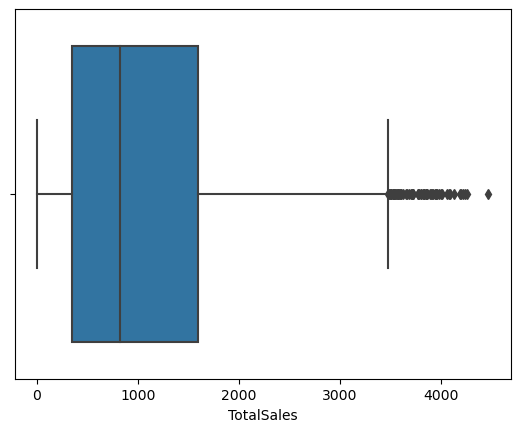

In [21]:
sns.boxplot(x=updated_data["TotalSales"])
plt.show()

In [22]:
Q1 = updated_data["TotalSales"].quantile(0.25)
Q3 = updated_data["TotalSales"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

updated_data = updated_data[(updated_data["TotalSales"] >= lower) & (updated_data["TotalSales"] <= upper)]

In [23]:
updated_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4938 entries, 0 to 5046
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   TransactionID   4938 non-null   int64         
 1   CustomerID      4938 non-null   int64         
 2   ProductID       4938 non-null   int64         
 3   Quantity        4938 non-null   int64         
 4   UnitPrice       4938 non-null   float64       
 5   Discount        4938 non-null   float64       
 6   Region          4938 non-null   object        
 7   PaymentMethod   4938 non-null   object        
 8   InvoiceDate     4938 non-null   datetime64[ns]
 9   Year            4938 non-null   int64         
 10  Month           4938 non-null   int64         
 11  Weekday         4938 non-null   object        
 12  TotalSales      4938 non-null   float64       
 13  EffectivePrice  4938 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(6), object(3)
me

# Univariate Analysis

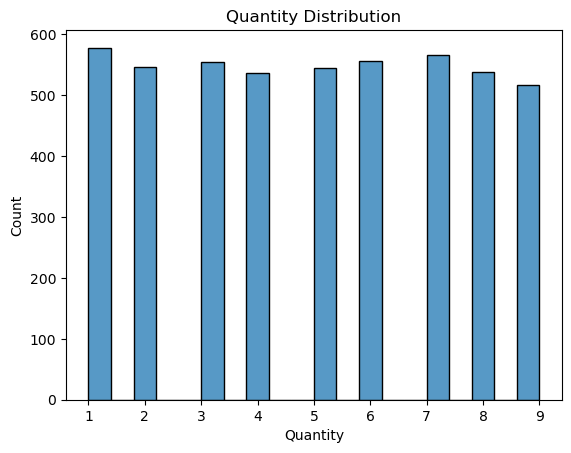

In [24]:
sns.histplot(updated_data["Quantity"], bins=20)
plt.title("Quantity Distribution")
plt.show()

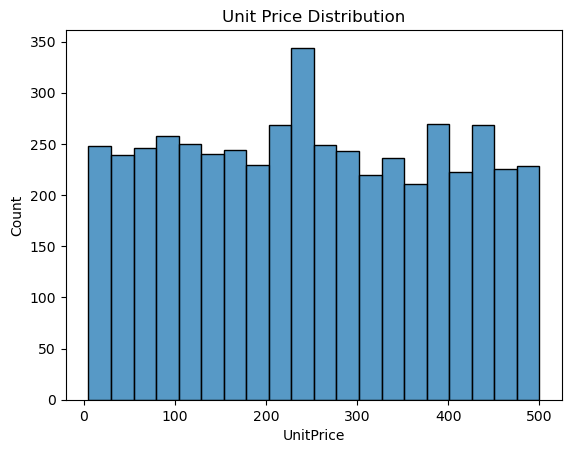

In [25]:
sns.histplot(updated_data["UnitPrice"], bins=20)
plt.title("Unit Price Distribution")
plt.show()

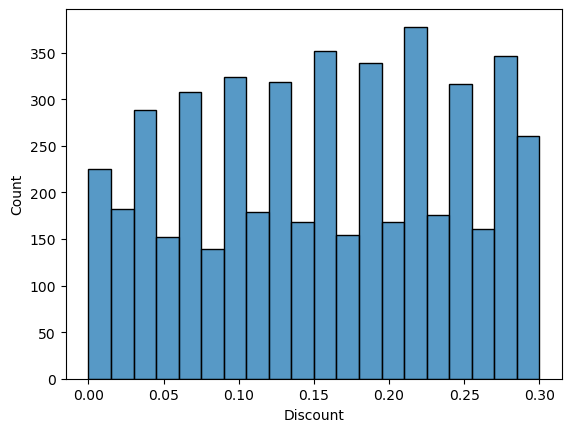

In [26]:
sns.histplot(updated_data["Discount"], bins=20)
plt.show()

# Sales Analysis

In [27]:
updated_data["TotalSales"].sum()

5121515.4792

In [28]:
# Average Order
updated_data["TotalSales"].mean()

1037.1639285540707

# Regional Sales Analysis

In [29]:
region_sales = updated_data.groupby("Region")["TotalSales"].sum().sort_values(ascending=False)

region_sales

Region
Port Harcourt    2.206349e+06
Abuja            1.016012e+06
Kano             9.586636e+05
Lagos            9.404904e+05
Name: TotalSales, dtype: float64

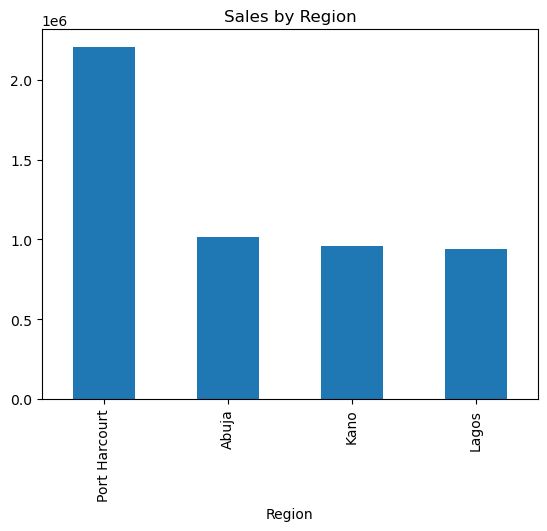

In [30]:
region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.show()

# Payment Method Analysis

In [31]:
updated_data["PaymentMethod"].value_counts()

Cash        2028
Transfer    1002
Card         957
POS          951
Name: PaymentMethod, dtype: int64

# Monthly Sales Trend

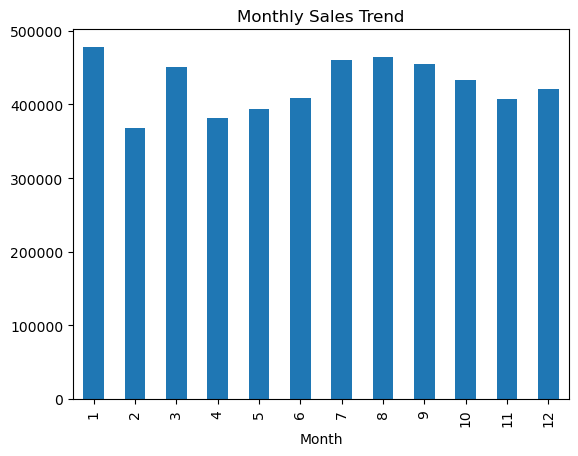

In [32]:
monthly_sales = updated_data.groupby("Month")["TotalSales"].sum()

monthly_sales.plot(kind="bar")
plt.title("Monthly Sales Trend")
plt.show()

In [33]:
average_monthly_sales=monthly_sales.mean()

In [34]:
average_monthly_sales

426792.9566

In [35]:
monthly_sales

Month
1     478139.15845
2     368437.24850
3     450552.87395
4     381932.43710
5     393291.05905
6     408456.47390
7     460073.03320
8     465030.48565
9     455174.65375
10    432957.15330
11    406964.30200
12    420506.60035
Name: TotalSales, dtype: float64

In [36]:
updated_data.head()

,TransactionID,CustomerID,ProductID,Quantity,UnitPrice,Discount,Region,PaymentMethod,InvoiceDate,Year,Month,Weekday,TotalSales,EffectivePrice
0,10000,1102,319,3,100.90,0.25,Kano,Card,2023-06-02,2023,6,Friday,227.0250,75.6750
1,10001,1435,325,9,134.57,0.27,Abuja,Card,2023-07-21,2023,7,Friday,884.1249,98.2361
2,10002,1860,254,1,258.73,0.06,Port Harcourt,POS,2023-11-17,2023,11,Friday,243.2062,243.2062
3,10003,1270,226,5,168.65,0.19,Port Harcourt,Transfer,2024-04-08,2024,4,Monday,683.0325,136.6065
4,10004,1106,317,2,430.95,0.28,Port Harcourt,Card,2023-01-11,2023,1,Wednesday,620.5680,310.2840


## Product Sales Per Customer & Region Analysis

In [37]:
product_region_sales = updated_data.groupby(['ProductID','Region'])['Quantity'].sum()
print(product_region_sales)

ProductID  Region       
200        Abuja              7
           Kano              23
           Lagos             30
           Port Harcourt     22
201        Abuja             19
           Kano              18
           Lagos             13
           Port Harcourt     63
202        Abuja              4
           Kano              17
           Lagos             35
           Port Harcourt     35
203        Abuja             40
           Kano              41
           Lagos             24
           Port Harcourt     38
204        Abuja             11
           Kano               9
           Lagos             16
           Port Harcourt     12
205        Abuja             23
           Kano              16
           Lagos              9
           Port Harcourt     49
206        Abuja             11
           Kano              12
           Lagos             17
           Port Harcourt     37
207        Abuja             37
           Kano              13
           Lago

In [38]:
pivot_table = updated_data.pivot_table(values='Quantity',
                             index='ProductID',
                             columns='Region',
                             aggfunc='sum')

print(pivot_table)

Region     Abuja  Kano  Lagos  Port Harcourt
ProductID                                   
200          7.0  23.0   30.0           22.0
201         19.0  18.0   13.0           63.0
202          4.0  17.0   35.0           35.0
203         40.0  41.0   24.0           38.0
204         11.0   9.0   16.0           12.0
205         23.0  16.0    9.0           49.0
206         11.0  12.0   17.0           37.0
207         37.0  13.0   12.0           47.0
208         19.0   8.0   46.0           35.0
209         37.0  28.0   20.0           63.0
210         34.0  26.0   34.0           24.0
211         14.0  26.0   16.0           38.0
212         21.0  54.0   29.0           54.0
213         25.0  26.0    4.0           40.0
214         23.0  42.0   18.0           77.0
215         20.0  21.0   70.0           33.0
216         46.0  34.0   28.0           88.0
217         29.0  25.0   16.0           61.0
218         28.0   9.0   32.0           39.0
219         16.0   4.0   16.0           63.0
220       

In [39]:
top_region_product = pivot_table.idxmax(axis=1)
print(top_region_product)

ProductID
200            Lagos
201    Port Harcourt
202            Lagos
203             Kano
204            Lagos
205    Port Harcourt
206    Port Harcourt
207    Port Harcourt
208            Lagos
209    Port Harcourt
210            Abuja
211    Port Harcourt
212             Kano
213    Port Harcourt
214    Port Harcourt
215            Lagos
216    Port Harcourt
217    Port Harcourt
218    Port Harcourt
219    Port Harcourt
220    Port Harcourt
221    Port Harcourt
222    Port Harcourt
223            Lagos
224            Abuja
225    Port Harcourt
226    Port Harcourt
227    Port Harcourt
228    Port Harcourt
229            Lagos
230    Port Harcourt
231    Port Harcourt
232            Abuja
233    Port Harcourt
234            Abuja
235            Abuja
236    Port Harcourt
237    Port Harcourt
238    Port Harcourt
239    Port Harcourt
240    Port Harcourt
241    Port Harcourt
242            Lagos
243    Port Harcourt
244            Abuja
245    Port Harcourt
246    Port Harcourt
247

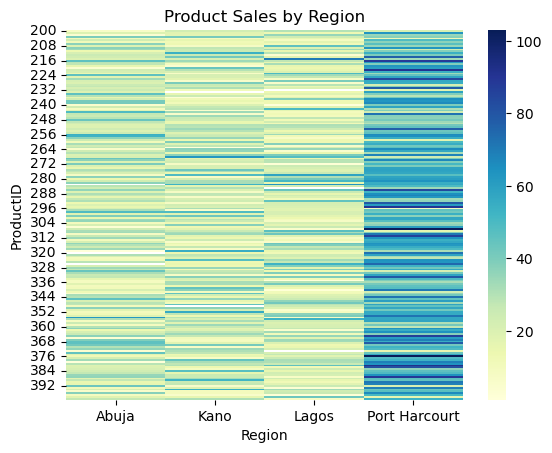

In [40]:
sns.heatmap(pivot_table, cmap="YlGnBu")
plt.title("Product Sales by Region")
plt.show()

In [41]:
#Product performance
product_sales = updated_data.groupby("ProductID")["TotalSales"].sum().sort_values(ascending=False)
product_sales

ProductID
365    53790.97210
216    41222.04920
283    40143.02820
367    39652.63025
286    39215.48920
333    39106.69480
380    37202.90740
394    36996.84870
214    36152.48190
298    35888.81780
281    35622.54680
256    35408.87700
212    34749.07780
361    34648.97670
278    34617.00330
310    34476.38510
331    34453.62390
237    34393.52480
355    34384.01620
345    34337.04075
348    34259.03185
217    33947.87980
257    33646.41360
289    33618.76440
270    33489.86240
267    33263.68050
353    33262.84885
268    32792.90180
315    32778.69030
386    32609.72870
316    32599.31950
224    32534.48890
307    32424.99540
226    32176.95595
350    31739.78150
378    31668.95790
203    31579.91750
369    31570.96985
275    31513.31890
389    31444.49120
356    31204.51690
258    31064.63650
271    30936.78840
241    30934.89325
276    30919.28180
265    30708.73250
327    30555.35010
354    30422.43070
300    30281.66390
318    30249.21110
324    30205.51680
221    29989.08110
25

In [42]:
#Customer spending
customer_sales = updated_data.groupby("CustomerID")["TotalSales"].sum().sort_values(ascending=False)
customer_sales

CustomerID
1038    17333.51130
1735    17204.44220
1276    16833.13880
1935    15981.33970
1516    15776.97665
1553    15656.79380
1970    15546.75900
1658    15221.22170
1961    15101.59440
1546    14914.20750
1496    14405.86440
1703    14313.48790
1957    14224.88930
1647    14051.02410
1550    13837.20980
1159    13555.60330
1219    13462.50980
1400    13389.70380
1525    13336.39430
1098    13332.37720
1187    13102.73340
1475    13081.63620
1747    12564.73040
1222    12450.01660
1574    12312.05960
1050    12142.75250
1663    12008.59950
1780    11945.02230
1866    11849.25210
1920    11845.67430
1669    11801.27160
1928    11747.39830
1064    11746.40730
1392    11686.79860
1499    11577.18460
1323    11492.07410
1363    11490.93350
1890    11414.78910
1865    11404.95150
1379    11291.39095
1786    11241.26470
1955    11176.28095
1822    11066.26660
1301    11019.30300
1771    11001.00890
1761    10989.86880
1657    10944.64250
1699    10942.60750
1788    10932.74200
1775    1

## Data Convert to CSV

In [43]:
updated_data.to_csv('data_preprocessed.csv', index=False)